# 01 — Personalization Loop v0

Offline-симулятор A/B-контура персонализации в compact 8D-пространстве.

Цель: проверить, сходится ли `PreferenceState.z_mean` к скрытому `z_target` синтетического пользователя.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

ROOT

WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/eq_personalization')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from personalization import FEATURE_NAMES_8D, SyntheticUser, run_personalization_session_v0
from personalization.metrics import session_summary
from personalization.plotting import plot_convergence, plot_final_vs_target


## 1. Создаём синтетического пользователя


In [3]:
z_target = np.array([0.30, 0.70, -0.20, 0.40, 0.10, 0.50, 0.60, -0.30])

user = SyntheticUser(
    z_target=z_target,
    noise_std=0.05,
    rng=np.random.default_rng(42),
)

pd.DataFrame({
    'feature': FEATURE_NAMES_8D,
    'z_target': z_target,
})

,feature,z_target
0,sub_bass,0.3
1,bass,0.7
2,lowmid,-0.2
3,warmth,0.4
4,presence,0.1
5,clarity,0.5
6,air,0.6
7,brightness,-0.3


## 2. Запускаем baseline A/B loop


In [4]:
result = run_personalization_session_v0(
    synthetic_user=user,
    n_steps=25,
    step_scale=0.6,
    lr=0.25,
    pair_strategy='random',
    seed=123,
)

summary = session_summary(result.final_state, z_target, result.distances)
summary

{'n_steps': 25.0,
 'initial_distance': 1.1597954053911406,
 'final_distance': 0.4069314478079509,
 'best_distance': 0.16358315259969805,
 'mean_distance': 0.6317369546811284}

## 3. Смотрим сходимость


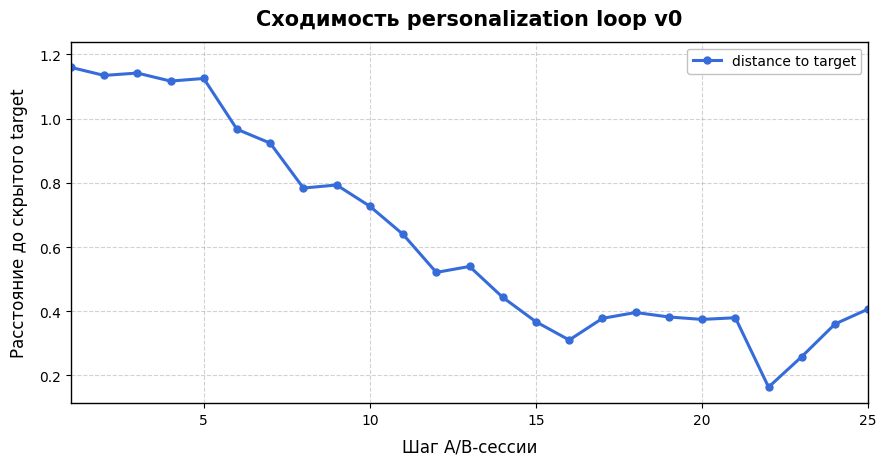

In [5]:
plot_convergence(result.distances)
plt.show()

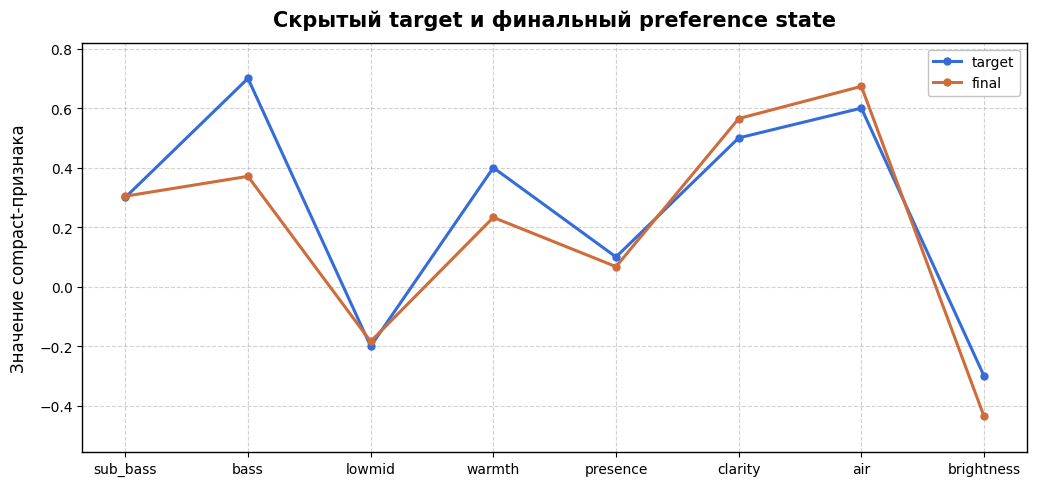

In [6]:
plot_final_vs_target(result.final_state.z_mean, z_target)
plt.show()

## Вывод по эксперименту personalization loop v0

В данном эксперименте был реализован базовый offline-симулятор контура персонализации `personalization loop v0`. Его задача — проверить, может ли простая A/B-логика приближать текущее состояние предпочтений пользователя к скрытому target-вектору в compact weighted 8D-пространстве.

В эксперименте используется синтетический пользователь со скрытым вектором предпочтений `z_target ∈ R^8`. Система этот вектор не знает и начинает с начального состояния `z_mean = [0, 0, 0, 0, 0, 0, 0, 0]`.

На каждом шаге `Pair Generator` выбирает случайное направление `d` в 8D-пространстве и формирует симметричную A/B-пару вокруг текущего состояния:

```python
z_A = z_mean + step_scale * d
z_B = z_mean - step_scale * d
```

Синтетический пользователь выбирает тот вариант, который ближе к скрытому z_target. Для этого используется utility-функция:
```python
utility(z) = -sum((z - z_target) ** 2)
```

После выбора система сдвигает текущий preference state в сторону предпочтённого варианта:
```python
direction = preferred - rejected
direction = direction / ||direction||
z_mean = z_mean + lr * direction
```
Основная метрика эксперимента — расстояние между текущим состоянием и скрытым target-вектором:
```python
distance_to_target = ||z_mean - z_target||
```

Полученные результаты показывают, что даже базовая стратегия обновления способна уменьшать расстояние между текущим `preference state` и скрытым `z_target`. На графике сходимости видно, что расстояние до target в течение A/B-сессии в целом снижается, что подтверждает работоспособность базового контура персонализации.

Сравнение финального `preference state` со скрытым target показывает, что система восстанавливает основное направление пользовательских предпочтений по большинству признаков weighted 8D-пространства. При этом остаются отдельные расхождения по некоторым осям, что ожидаемо для версии v0, так как генерация A/B-пар пока выполняется случайно и не учитывает информативность вопроса или неопределённость по отдельным признакам.

Таким образом, `personalization loop v0` можно рассматривать как sanity check и baseline для дальнейшего развития контура персонализации. Эксперимент подтверждает, что сама идея итеративного A/B-обновления preference state является работоспособной в контролируемой синтетической среде. Следующим шагом является разработка более интеллектуального `Pair Generator`, который будет выбирать A/B-кандидатов по наиболее неопределённым или информативным направлениям, а также добавление Directional Feedback и последующее подключение mapper-модели для перехода от compact-вектора к 23-полосной EQ-кривой.